In [1]:
import numpy as np

from pypower.api import runpf, ppoption
from pypower.case14 import case14
from pypower.case30 import case30
from pypower.case57 import case57
from pypower.case118 import case118

from pypower.idx_bus import PD, QD, VM, VA
from pypower.idx_brch import PF, QF


In [3]:
# -------------------------
# User configuration
# -------------------------
prefix= "data/ac_clean/"
PD_NPY = prefix+ "ACTIVSg2000_Pd_1680x200.npy"
QD_NPY = prefix+ "ACTIVSg2000_Qd_1680x200.npy"
Pd_profile_all = np.load(PD_NPY).astype(float)
Qd_profile_all = np.load(QD_NPY).astype(float)
print("Pd_profile_all:", Pd_profile_all.shape)
print("Qd_profile_all:", Qd_profile_all.shape)

# Time Horizon
T = 1400

# PF options
ppopt = ppoption(
    VERBOSE=0,
    OUT_ALL=0,
    PF_ALG=1,        # Newton AC PF
    PF_MAX_IT=30,
    PF_TOL=1e-8,
)

Pd_profile_all: (1680, 200)
Qd_profile_all: (1680, 200)


In [ ]:
def run_acpf(case_name, case_func, Pd_profile, Qd_profile):
    print(f"\nRunning for {case_name}...")
    base_ppc = case_func()
    base_Pd = base_ppc["bus"][:, PD].copy()
    base_Qd = base_ppc["bus"][:, QD].copy()

    activs_total_P = Pd_profile[:, :].sum(axis=1)
    activs_total_Q = Qd_profile[:, :].sum(axis=1)

    p_scale = activs_total_P / np.mean(activs_total_P)
    q_scale = activs_total_Q / np.mean(activs_total_Q)

    Pij_list, Qij_list = [], []
    V_list, theta_list = [], []
    P_list, Q_list = [], []

    for t in range(T):
        ppc = case_func()

        ppc["bus"][:, PD] = base_Pd * p_scale[t]
        ppc["bus"][:, QD] = base_Qd * q_scale[t]

        results, success = runpf(ppc, ppopt)

        if not success:
            print(f"{case_name}: not converged at time {t}, "
                  f"p_scale={p_scale[t]:.3f}, q_scale={q_scale[t]:.3f}")
            continue

        Pij_list.append(results["branch"][:, PF].copy())
        Qij_list.append(results["branch"][:, QF].copy())
        V_list.append(results["bus"][:, VM].copy())
        theta_list.append(results["bus"][:, VA].copy())
        P_list.append(results["bus"][:, PD].copy())
        Q_list.append(results["bus"][:, QD].copy())

    data = {
        "Pij": np.vstack(Pij_list),
        "Qij": np.vstack(Qij_list),
        "V": np.vstack(V_list),
        "theta": np.vstack(theta_list),
        "Pd": np.vstack(P_list),
        "Qd": np.vstack(Q_list),
    }

    out_file = prefix+f"{case_name}_{data['Pij'].shape[0]}.npy"
    np.save(out_file, data, allow_pickle=True)

    print(f"Saved {out_file}")
    print("Pij:", data["Pij"].shape)
    print("Qij:", data["Qij"].shape)
    print("V:", data["V"].shape)
    print("theta:", data["theta"].shape)

In [5]:
for case_name, case_func in zip(['case14', 'case30', 'case57', 'case118'], [case14, case30, case57, case118]):
    run_acpf(case_name, case_func, Pd_profile_all, Qd_profile_all)



Running for case14...
Saved case14_1400.npy
Pij: (1400, 20)
Qij: (1400, 20)
V: (1400, 14)
theta: (1400, 14)

Running for case30...
Saved case30_1400.npy
Pij: (1400, 41)
Qij: (1400, 41)
V: (1400, 30)
theta: (1400, 30)

Running for case57...
Saved case57_1400.npy
Pij: (1400, 80)
Qij: (1400, 80)
V: (1400, 57)
theta: (1400, 57)

Running for case118...
Saved case118_1400.npy
Pij: (1400, 186)
Qij: (1400, 186)
V: (1400, 118)
theta: (1400, 118)



### Quick inspection


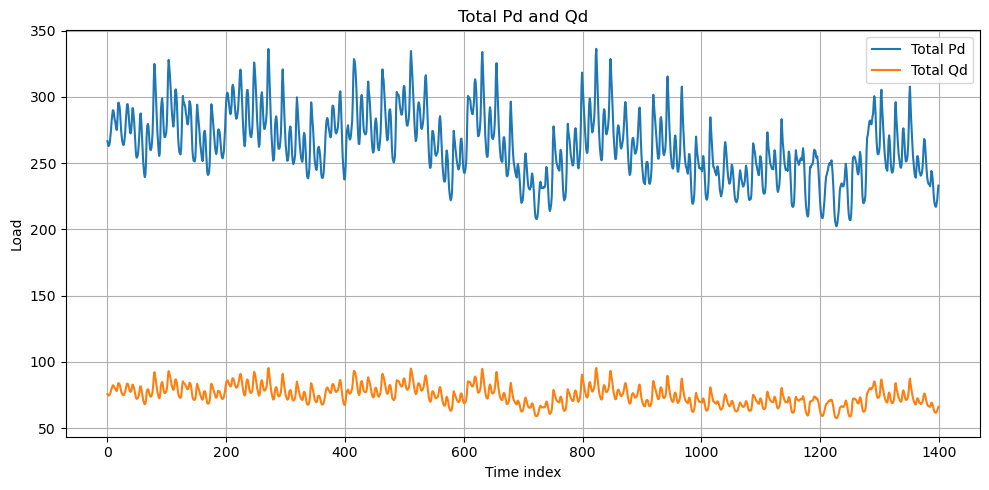

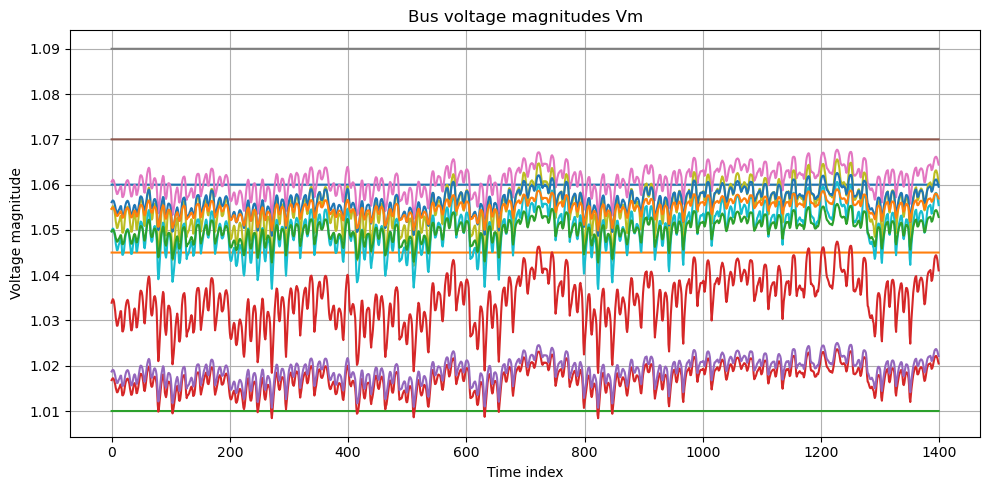

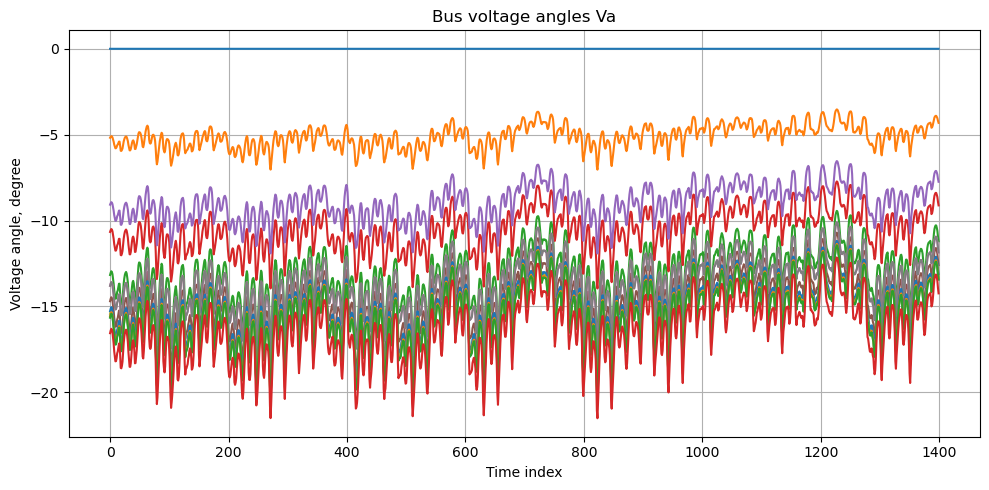

In [6]:
import matplotlib.pyplot as plt

file = prefix+f"case14_{T}.npy"
data = np.load(file, allow_pickle=True).item()

Pd = data["Pd"]
Qd = data["Qd"]
Vm = data["V"]
Va = data["theta"]

T = Pd.shape[0]
t = np.arange(T)

plt.figure(figsize=(10, 5))
plt.plot(t, Pd.sum(axis=1), label="Total Pd")
plt.plot(t, Qd.sum(axis=1), label="Total Qd")
plt.xlabel("Time index")
plt.ylabel("Load")
plt.title("Total Pd and Qd")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, Vm)
plt.xlabel("Time index")
plt.ylabel("Voltage magnitude")
plt.title("Bus voltage magnitudes Vm")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, Va)
plt.xlabel("Time index")
plt.ylabel("Voltage angle, degree")
plt.title("Bus voltage angles Va")
plt.grid(True)
plt.tight_layout()
plt.show()